In [16]:
import numpy as np
import matplotlib.pyplot as plt
import random
from scipy.fft import fft
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [2]:
# load data
X = np.load('../data/processed/X.npy')
print(X.shape)

(9565, 240, 18)


In [3]:
# load anomaly indices and clusters
anomaly_indices = np.load('../data/processed/anomaly_indices.npy')
clusters = np.load('../data/processed/anomaly_clusters.npy')

In [4]:
# safety check
assert len(X) > np.max(anomaly_indices), "Anomaly indices exceed number of windows in X!"

# group sensor windows by cluster
cluster_windows = {}
n_clusters = len(np.unique(clusters))

for c in range(n_clusters):
    cluster_indices = anomaly_indices[clusters == c]
    cluster_windows[c] = X[cluster_indices]

print("Raw signal windows grouped by cluster")

Raw signal windows grouped by cluster


Cluster 0: 7 windows


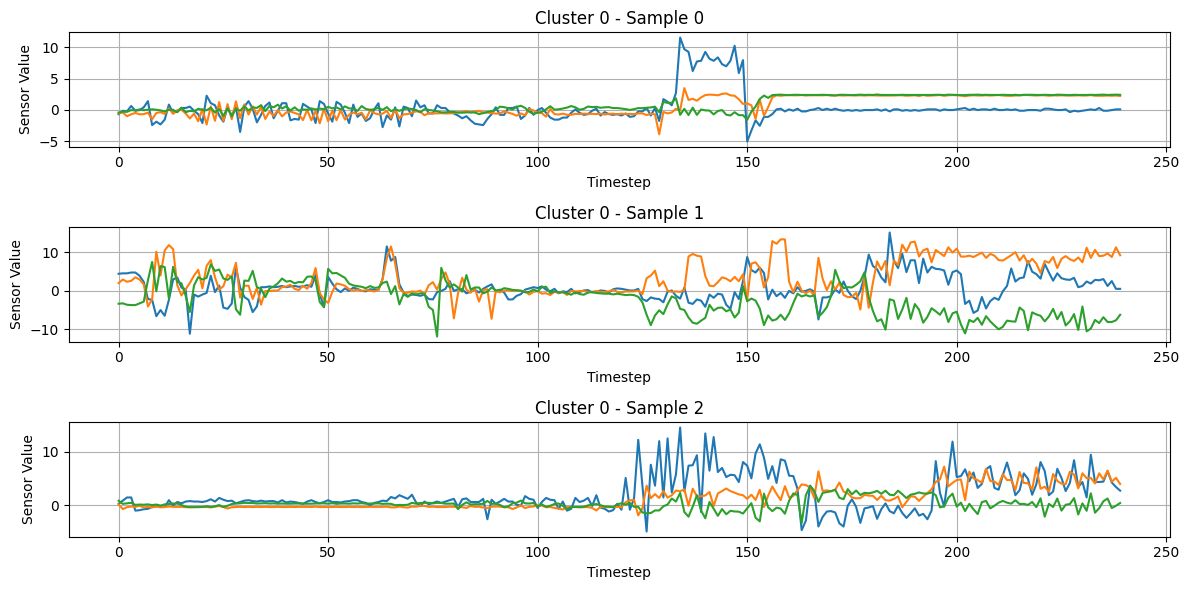

Cluster 1: 24 windows


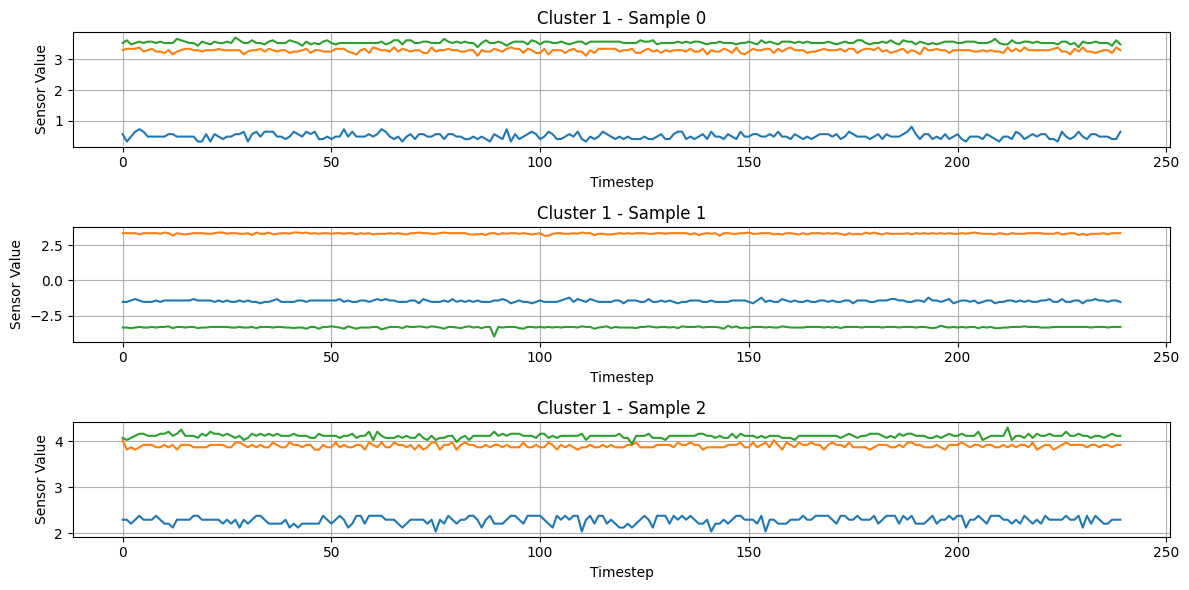

Cluster 2: 31 windows


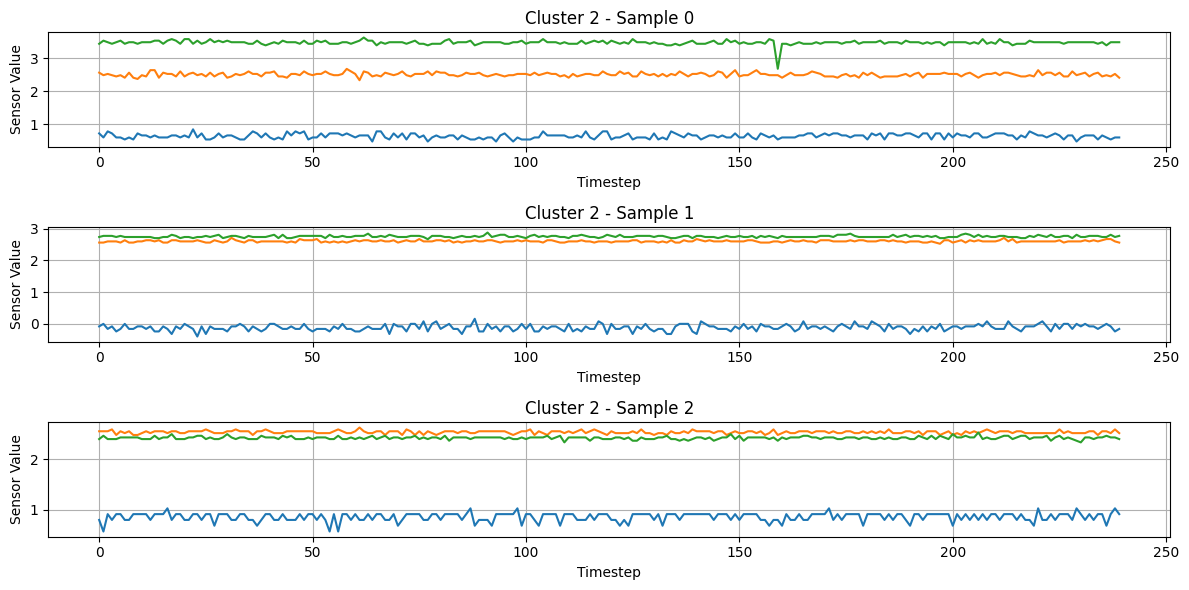

Cluster 3: 130 windows


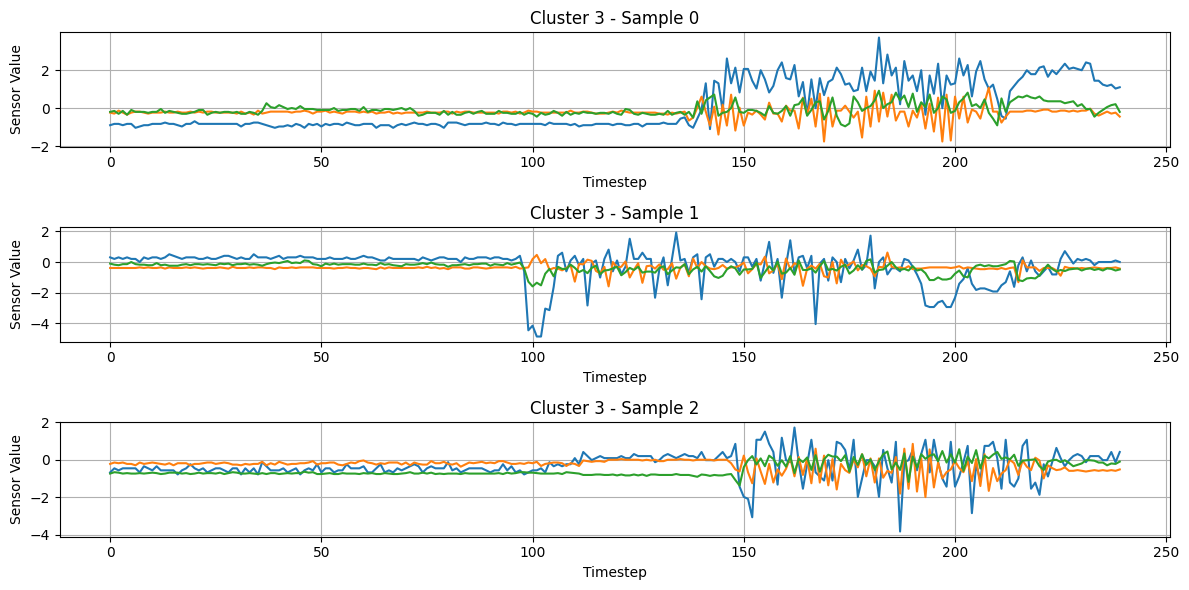

In [5]:
# visualize 3 random sample from each cluster
for c in range(n_clusters):
    windows = cluster_windows[c]
    print(f"Cluster {c}: {windows.shape[0]} windows")

    plt.figure(figsize=(12, 6))
    for i in range(3):
        idx = random.randint(0, len(windows) - 1)
        plt.subplot(3, 1, i + 1)
        plt.plot(windows[idx][:, :3])
        plt.title(f"Cluster {c} - Sample {i}")
        plt.xlabel('Timestep')
        plt.ylabel('Sensor Value')
        plt.grid(True)

    plt.tight_layout()
    plt.show()

In [6]:
# evaluate signal statistics
def compute_signal_stats(windows):
    mean = np.mean(windows, axis=1)
    std = np.std(windows, axis=1)
    amplitude = np.max(windows, axis=1) - np.min(windows, axis=1)
    energy = np.sum(windows ** 2, axis=1)

    return {
        'mean': mean,
        'std': std,
        'amplitude': amplitude, 
        'energy': energy
    }

In [8]:
# nap sensor indices to actual signal names (from  preprocessing)
signal_dim_counts = {
    "signals-bh3-acc.csv": 3, 
    "signals-bh3-bb.csv": 1,
    "signals-bh3-br.csv": 1,
    "signals-bh3-ecg.csv": 1,
    "signals-bh3-hr.csv": 1,
    "signals-bh3-hr_confidence.csv": 1,
    "signals-bh3-rr.csv": 1,
    "signals-bh3-rsp.csv": 1,
    "signals-e4-acc.csv": 3,
    "signals-e4-bvp.csv": 1,
    "signals-e4-eda.csv": 1,
    "signals-e4-hr.csv": 1,
    "signals-e4-ibi.csv": 1,
    "signals-e4-skt.csv": 1
}

# generate ordered list of signal names
sensor_names = []
for file, dim in signal_dim_counts.items():
    base_name = file.replace(".csv", "")
    if dim == 1:
        sensor_names.append(base_name)
    else:
        for i in range(1, dim + 1):
            sensor_names.append(f"{base_name}_{i}")

# sanity check
assert len(sensor_names) == 18, f"Expected 18 sensor names, got {len(sensor_names)}"
print("Sensor index mapping loaded successfully:")
for i, name in enumerate(sensor_names):
    print(f"{i:2d}: {name}")

Sensor index mapping loaded successfully:
 0: signals-bh3-acc_1
 1: signals-bh3-acc_2
 2: signals-bh3-acc_3
 3: signals-bh3-bb
 4: signals-bh3-br
 5: signals-bh3-ecg
 6: signals-bh3-hr
 7: signals-bh3-hr_confidence
 8: signals-bh3-rr
 9: signals-bh3-rsp
10: signals-e4-acc_1
11: signals-e4-acc_2
12: signals-e4-acc_3
13: signals-e4-bvp
14: signals-e4-eda
15: signals-e4-hr
16: signals-e4-ibi
17: signals-e4-skt


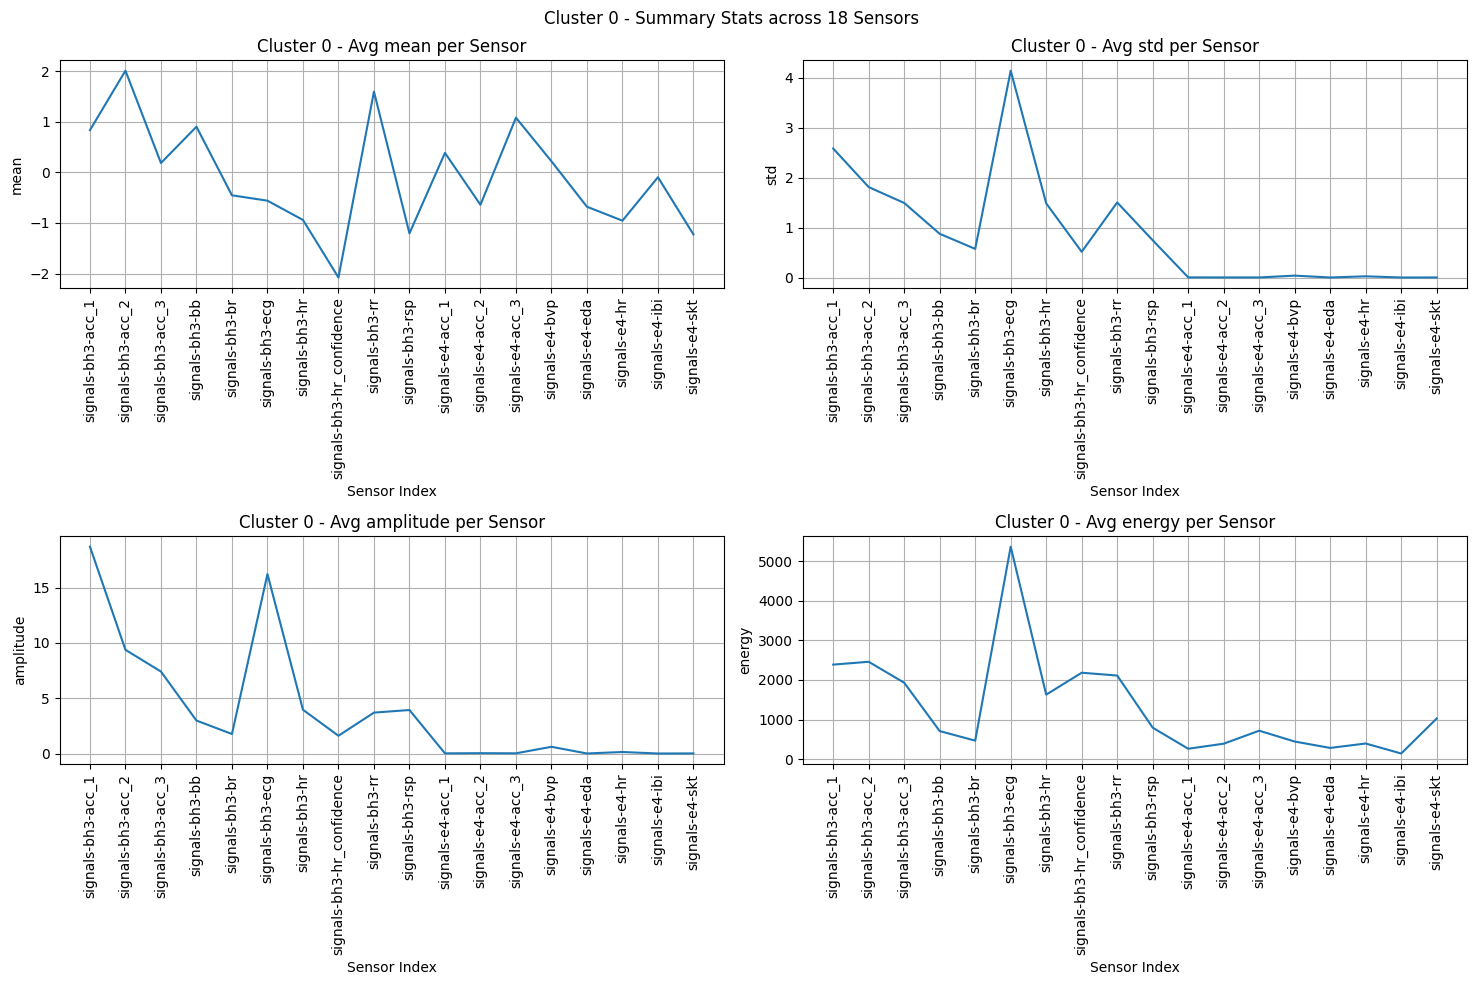

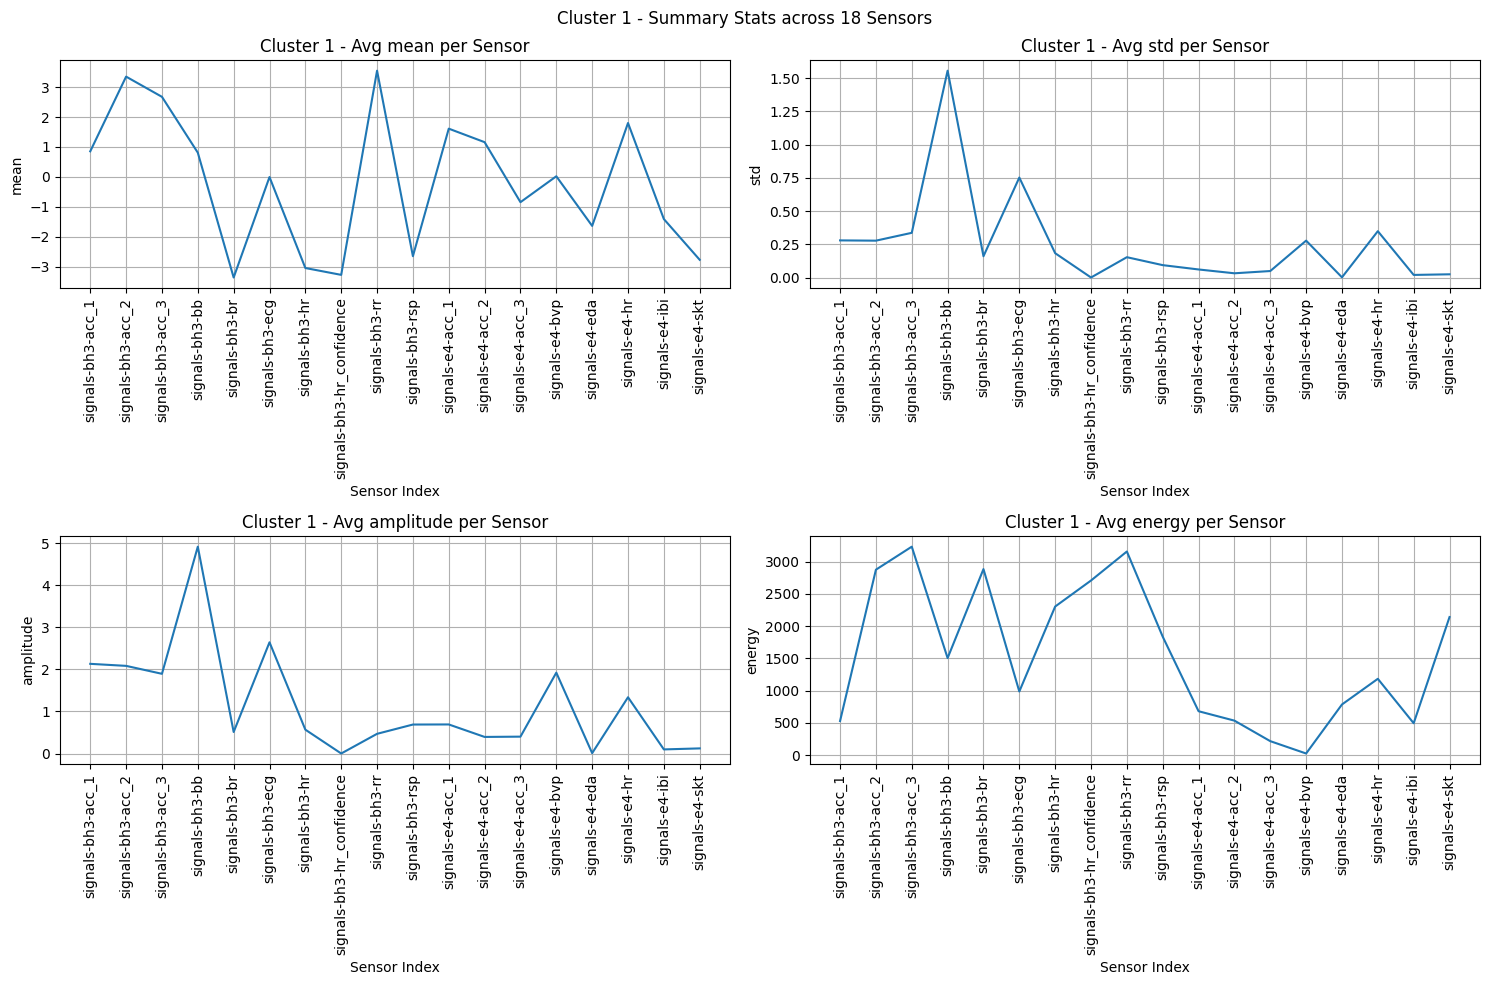

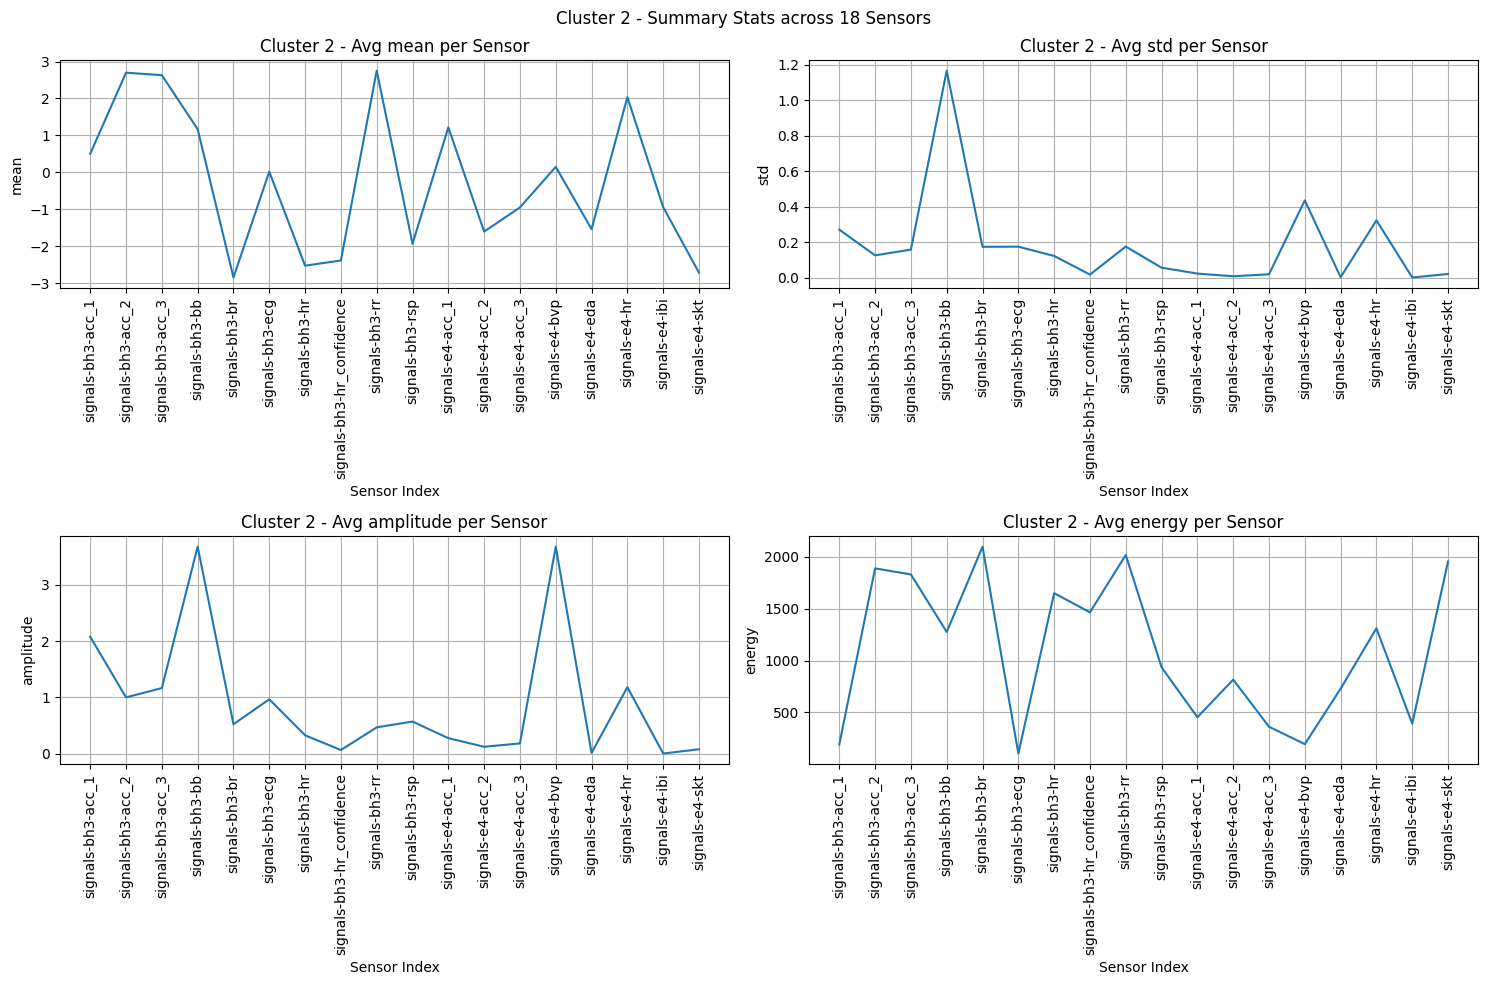

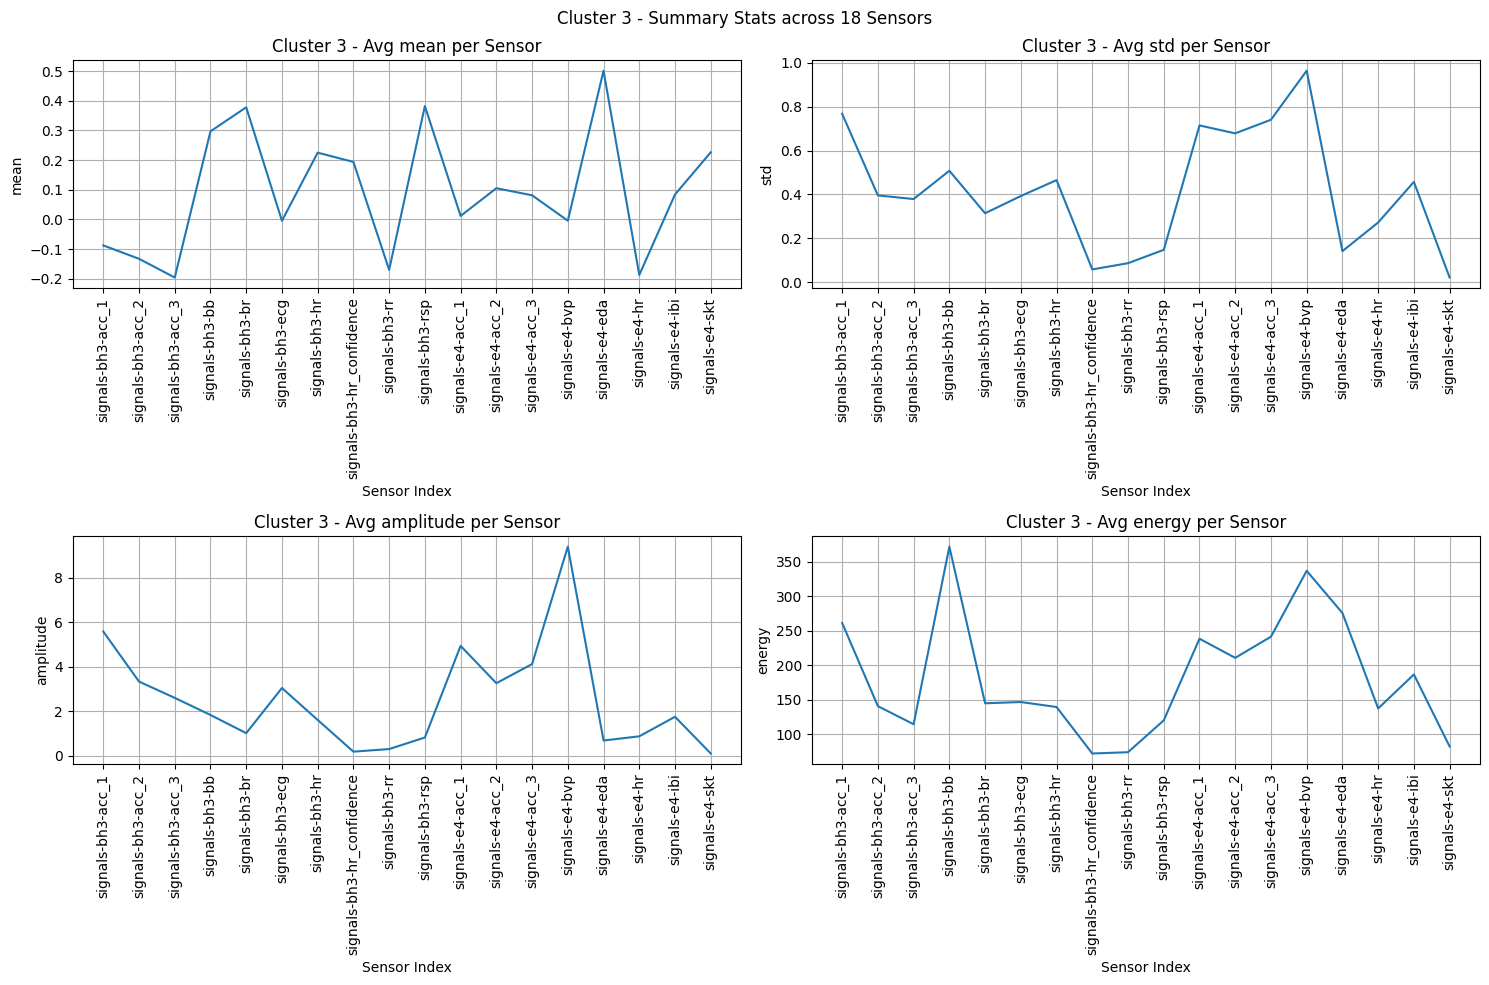

In [11]:
# store all cluster stats
cluster_stat_summaries = {}

for c in range(n_clusters):
    windows = cluster_windows[c]
    stats = compute_signal_stats(windows)

    # store for later comparison
    cluster_stat_summaries[c] = stats

    # visualization
    plt.figure(figsize=(15, 10))
    for i, (name, values) in enumerate(stats.items()):
        plt.subplot(2, 2, i+1)
        plt.plot(np.mean(values, axis=0)) # mean across all windows
        plt.xticks(ticks=np.arange(len(sensor_names)), labels=sensor_names, rotation=90)
        plt.title(f"Cluster {c} - Avg {name} per Sensor")
        plt.xlabel('Sensor Index')
        plt.ylabel(name)
        plt.grid(True)
    plt.suptitle(f"Cluster {c} - Summary Stats across 18 Sensors")
    plt.tight_layout()
    plt.show()

In [13]:
# compute global means of stats across all clusters
global_stats = {}
for stat_name in ['mean', 'std', 'amplitude', 'energy']:
    cluster_means = [np.mean(cluster_stat_summaries[c][stat_name], axis=0)
                     for c in cluster_stat_summaries]
    stacked = np.stack(cluster_means)
    global_stats[stat_name] = np.mean(stacked, axis=0)

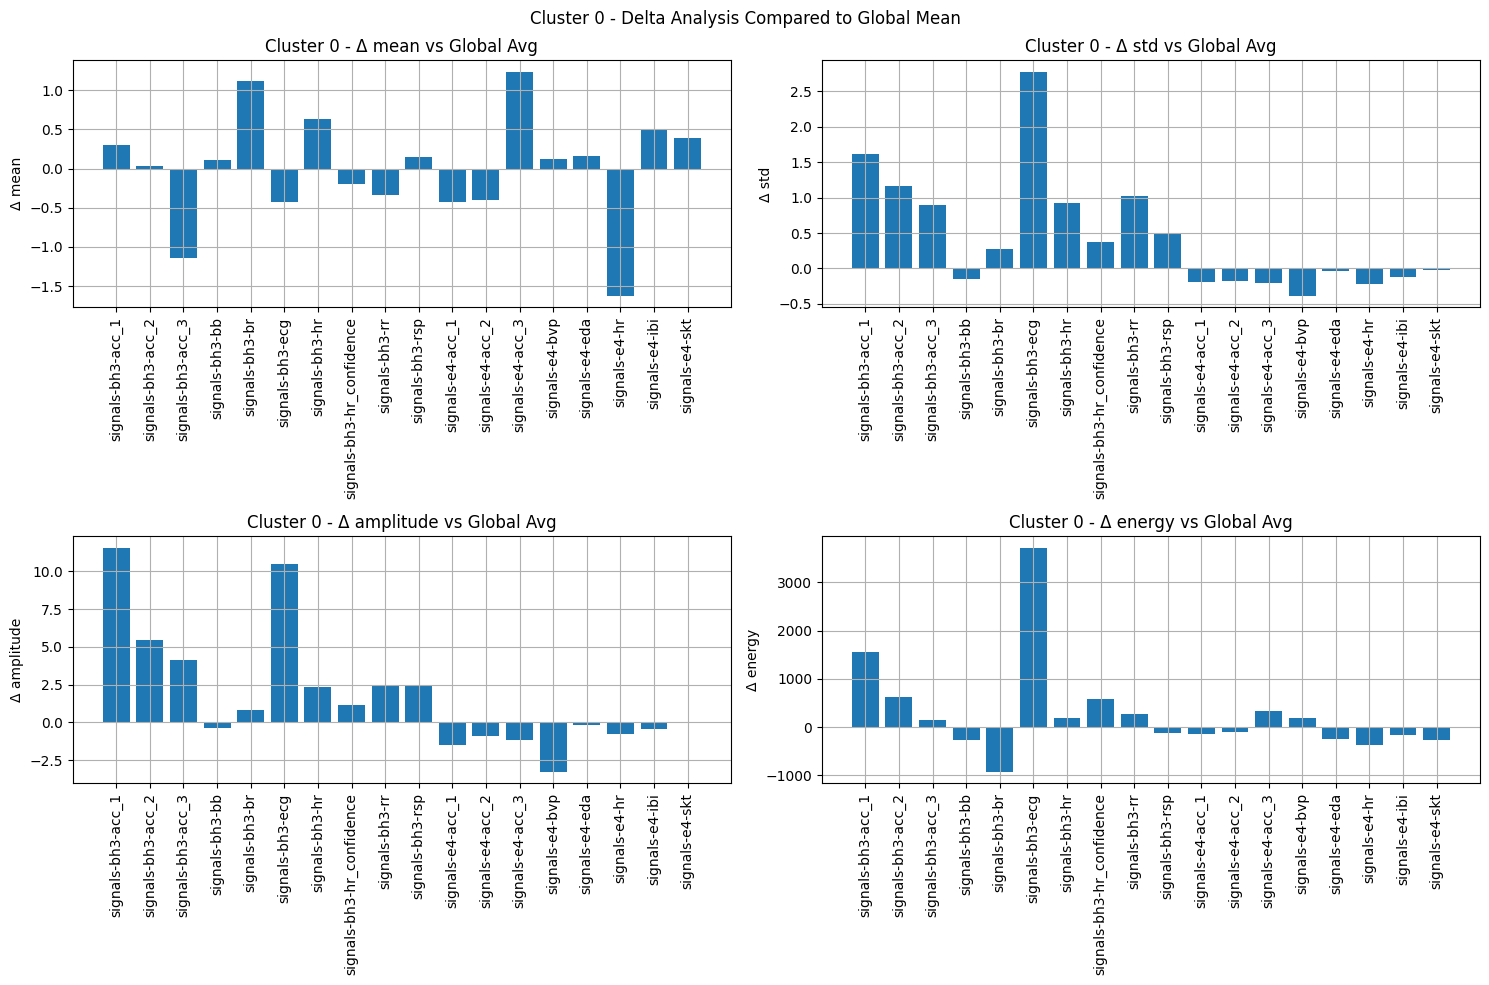

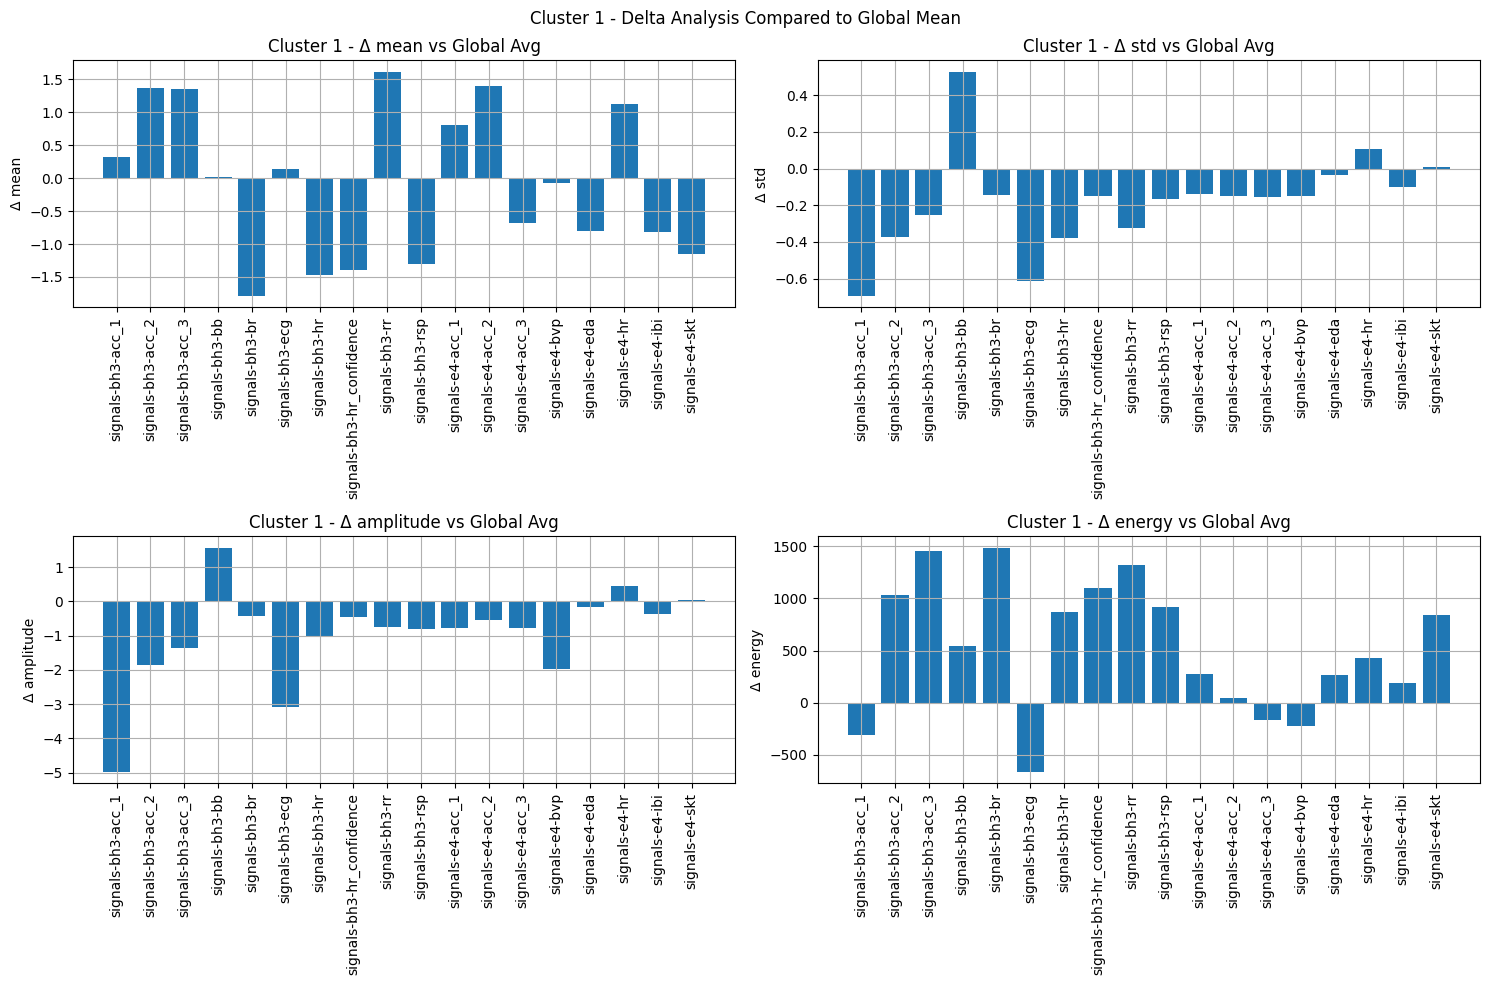

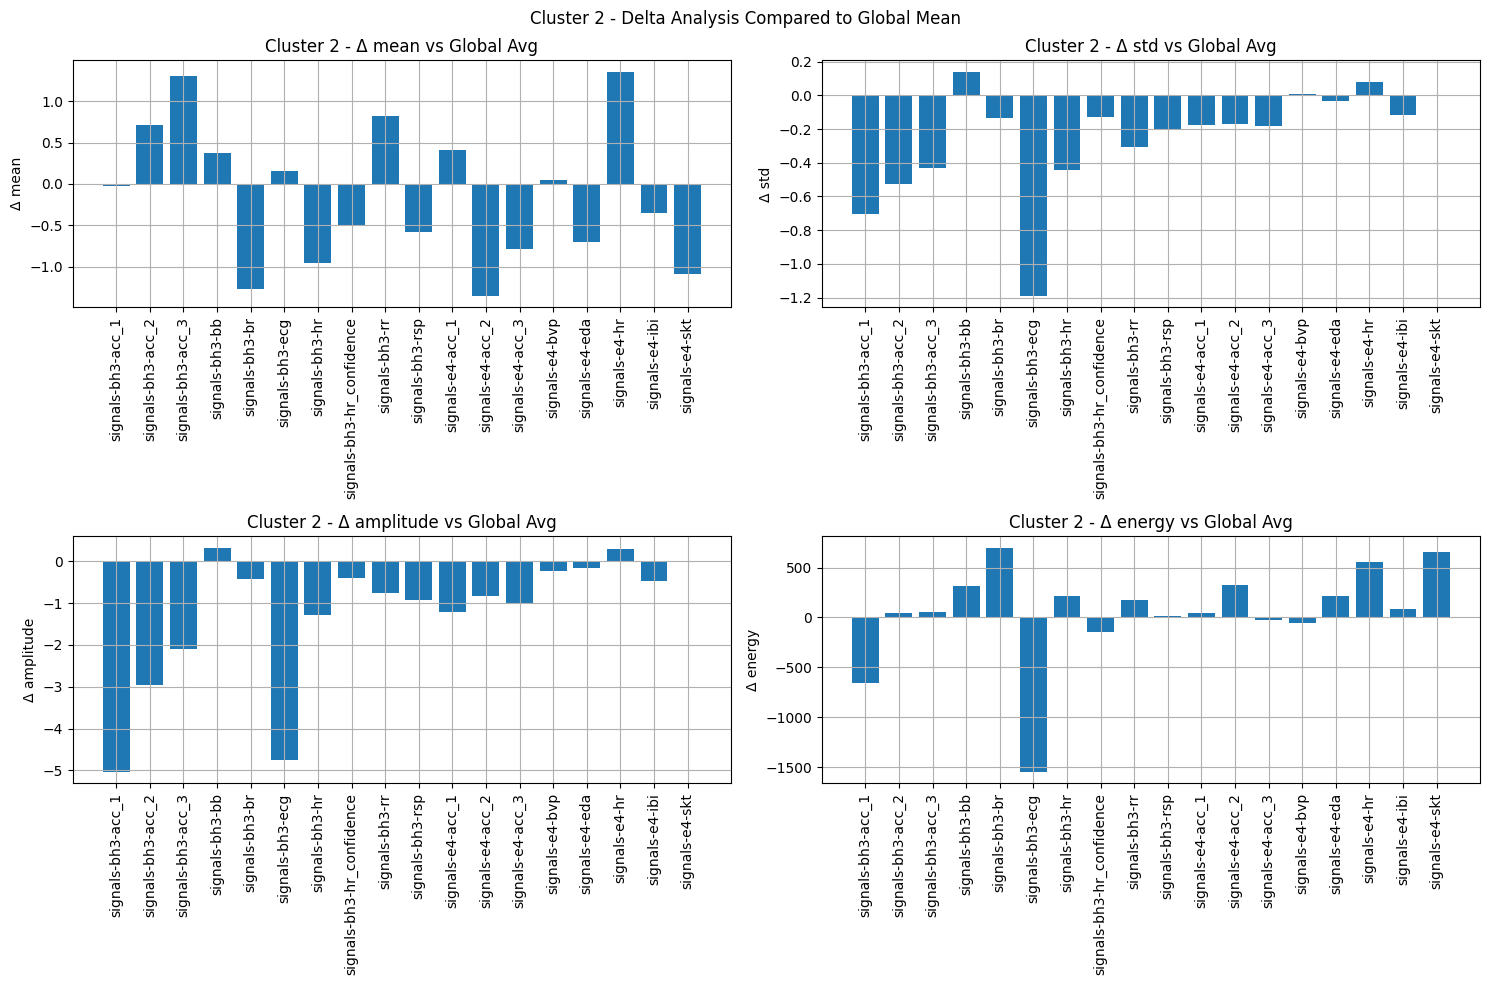

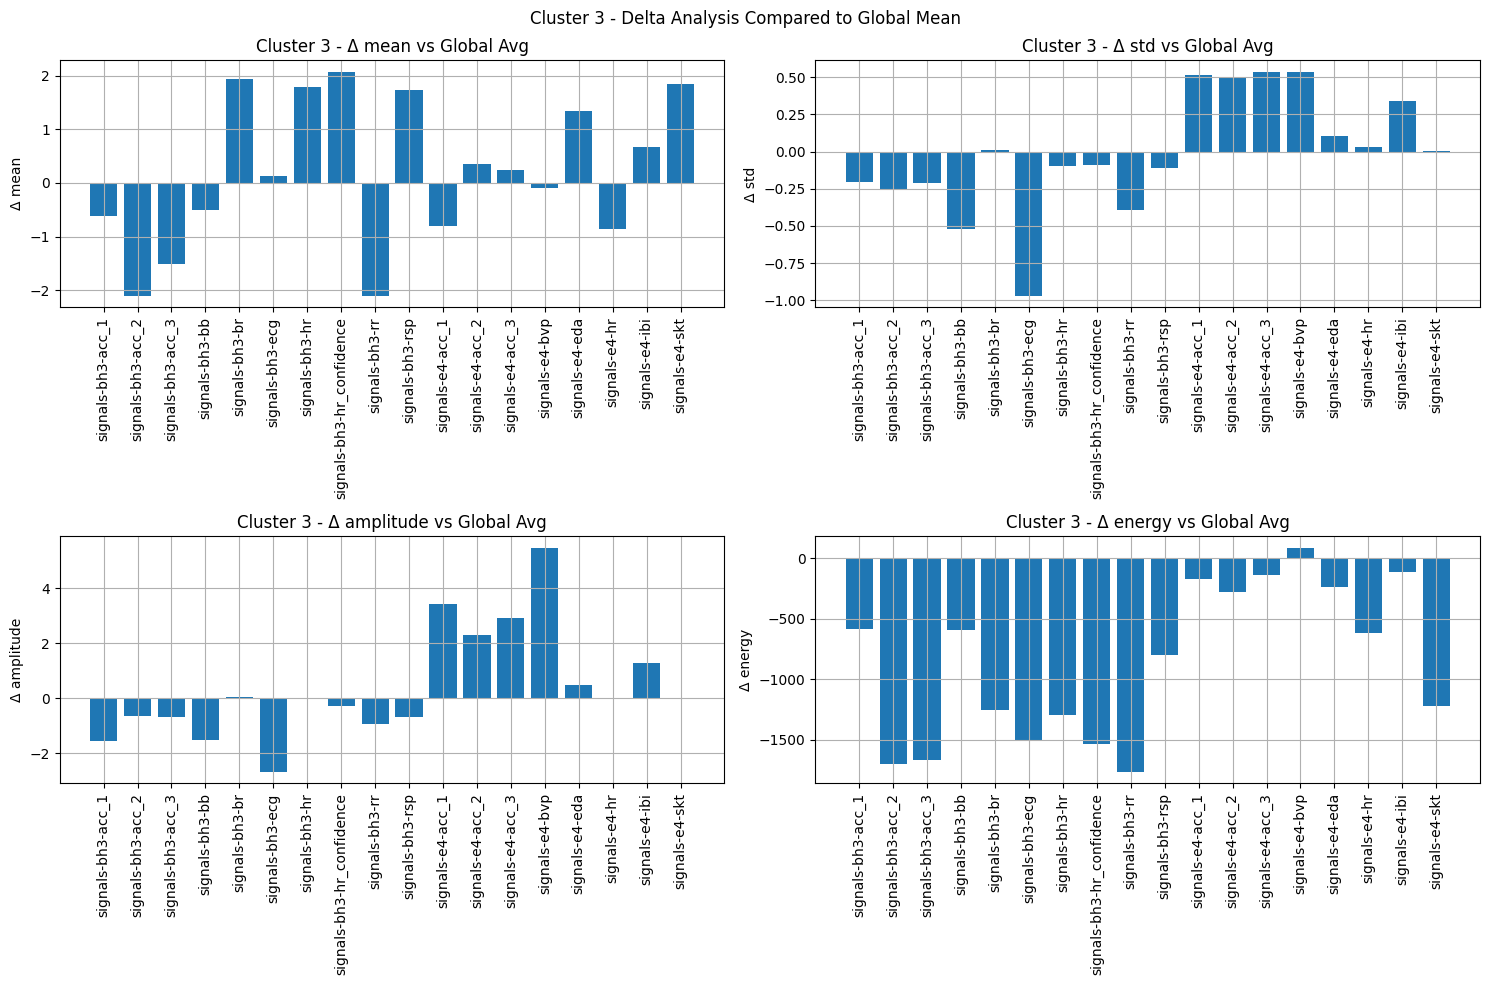

In [15]:
# plot delta stats (cluster - global average)
for c in cluster_stat_summaries:
    cluster_stats = cluster_stat_summaries[c]

    plt.figure(figsize=(15, 10))
    for i, stat_name in enumerate(['mean', 'std', 'amplitude', 'energy']):
        delta = np.mean(cluster_stats[stat_name], axis=0) - global_stats[stat_name]

        plt.subplot(2, 2, i+1)
        plt.bar(sensor_names, delta)
        plt.xticks(rotation=90)
        plt.title(f"Cluster {c} - Δ {stat_name} vs Global Avg")
        plt.ylabel(f"Δ {stat_name}")
        plt.grid(True)

    plt.suptitle(f"Cluster {c} - Delta Analysis Compared to Global Mean")
    plt.tight_layout()
    plt.show()

In [17]:
# apply fast fourier transform to capture rhythmic or periodic differences across clusters
def compute_fft_features(windows):
    num_sensors = windows.shape[2]
    avg_power = np.zeros(num_sensors)
    dom_freq_idx = np.zeros(num_sensors)

    for sensor in range(num_sensors):
        sensor_signals = windows[:, :, sensor]
        fft_vals = np.abs(fft(sensor_signals, axis=1))
        fft_vals = fft_vals[:, :fft_vals.shape[1] // 2] # keep only positive frequencies

        avg_power[sensor] = np.mean(fft_vals)
        dom_freq_idx[sensor] = np.argmax(np.mean(fft_vals, axis=0))

    return avg_power, dom_freq_idx

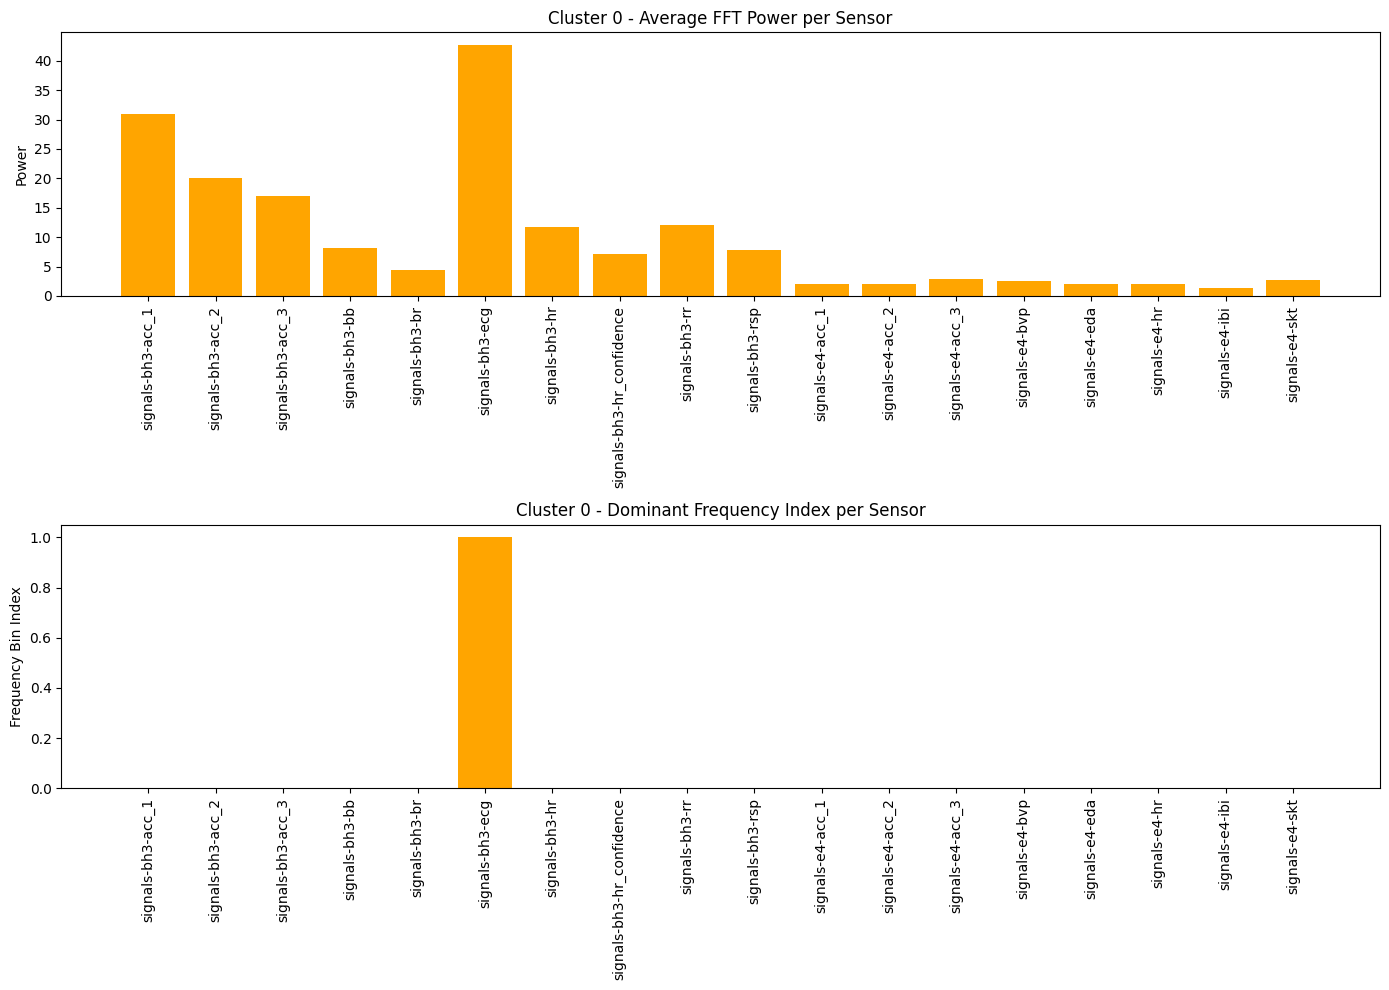

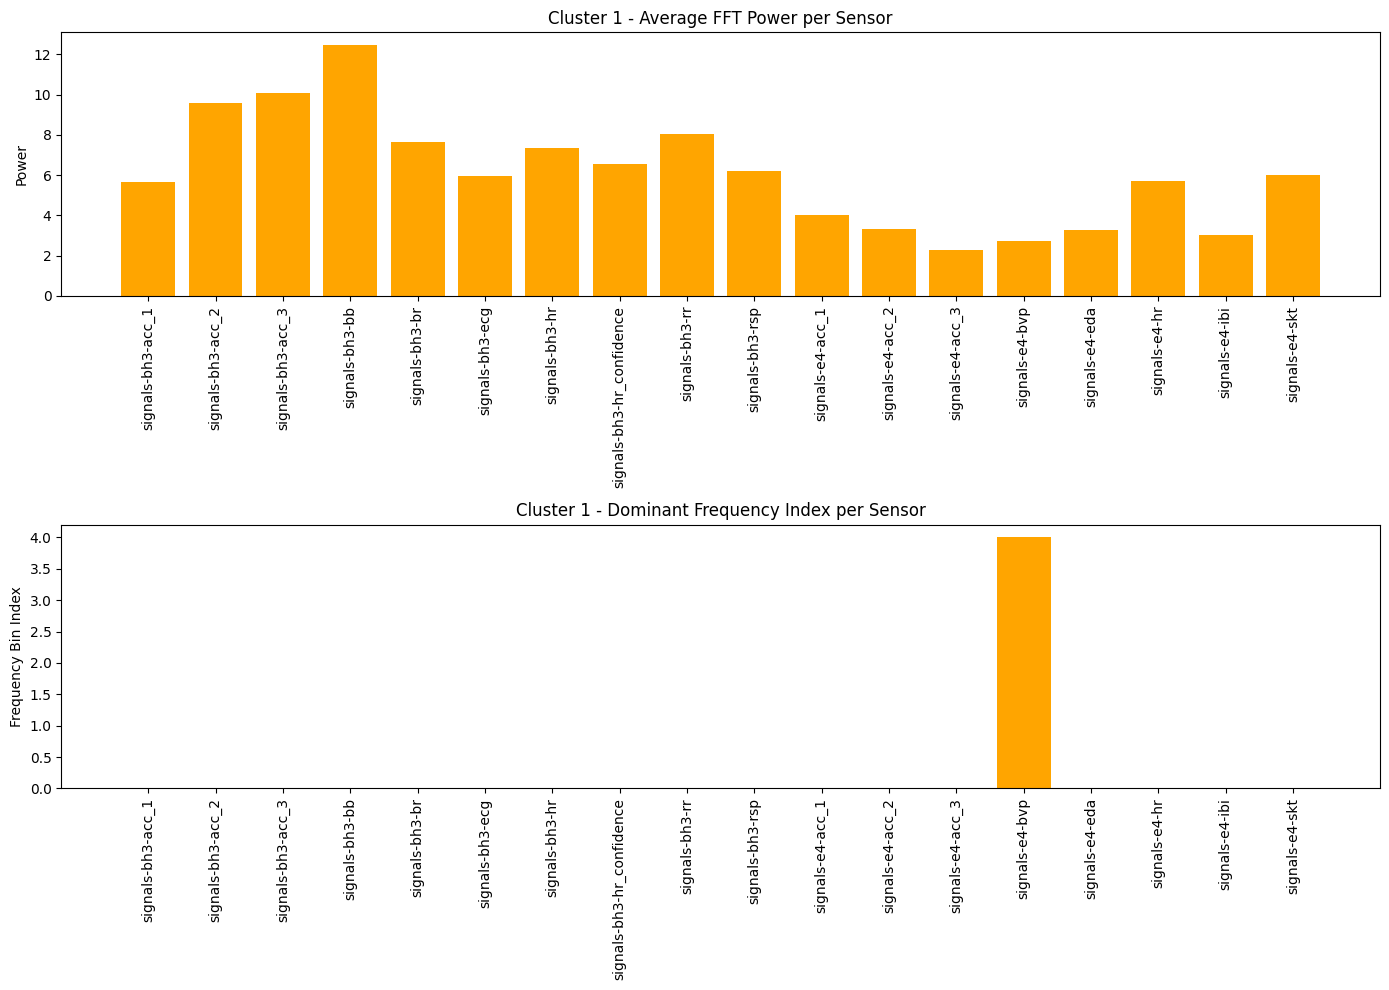

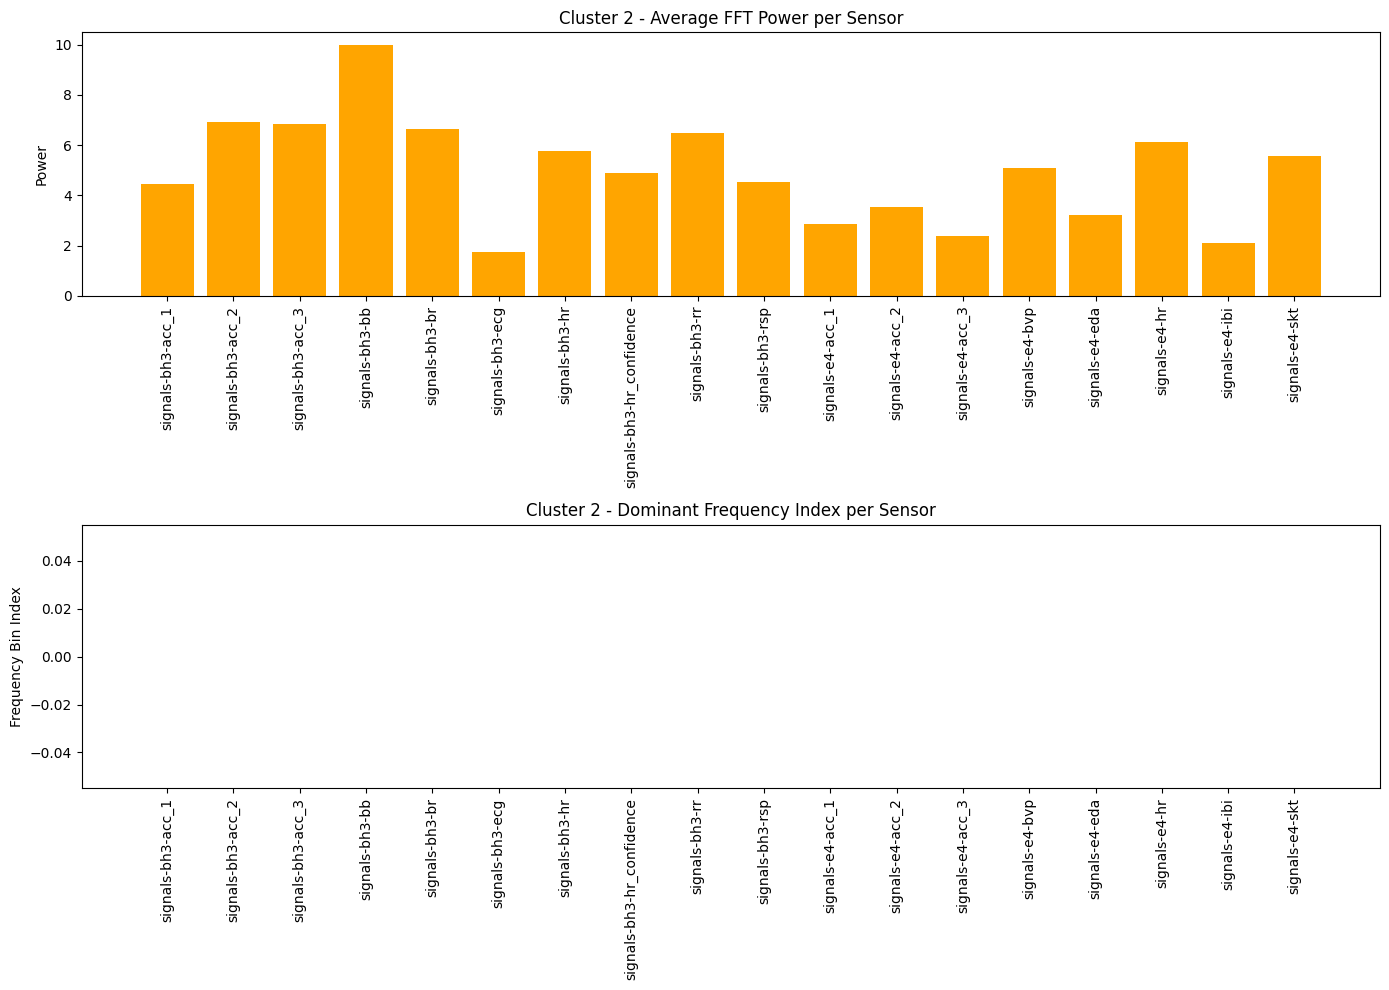

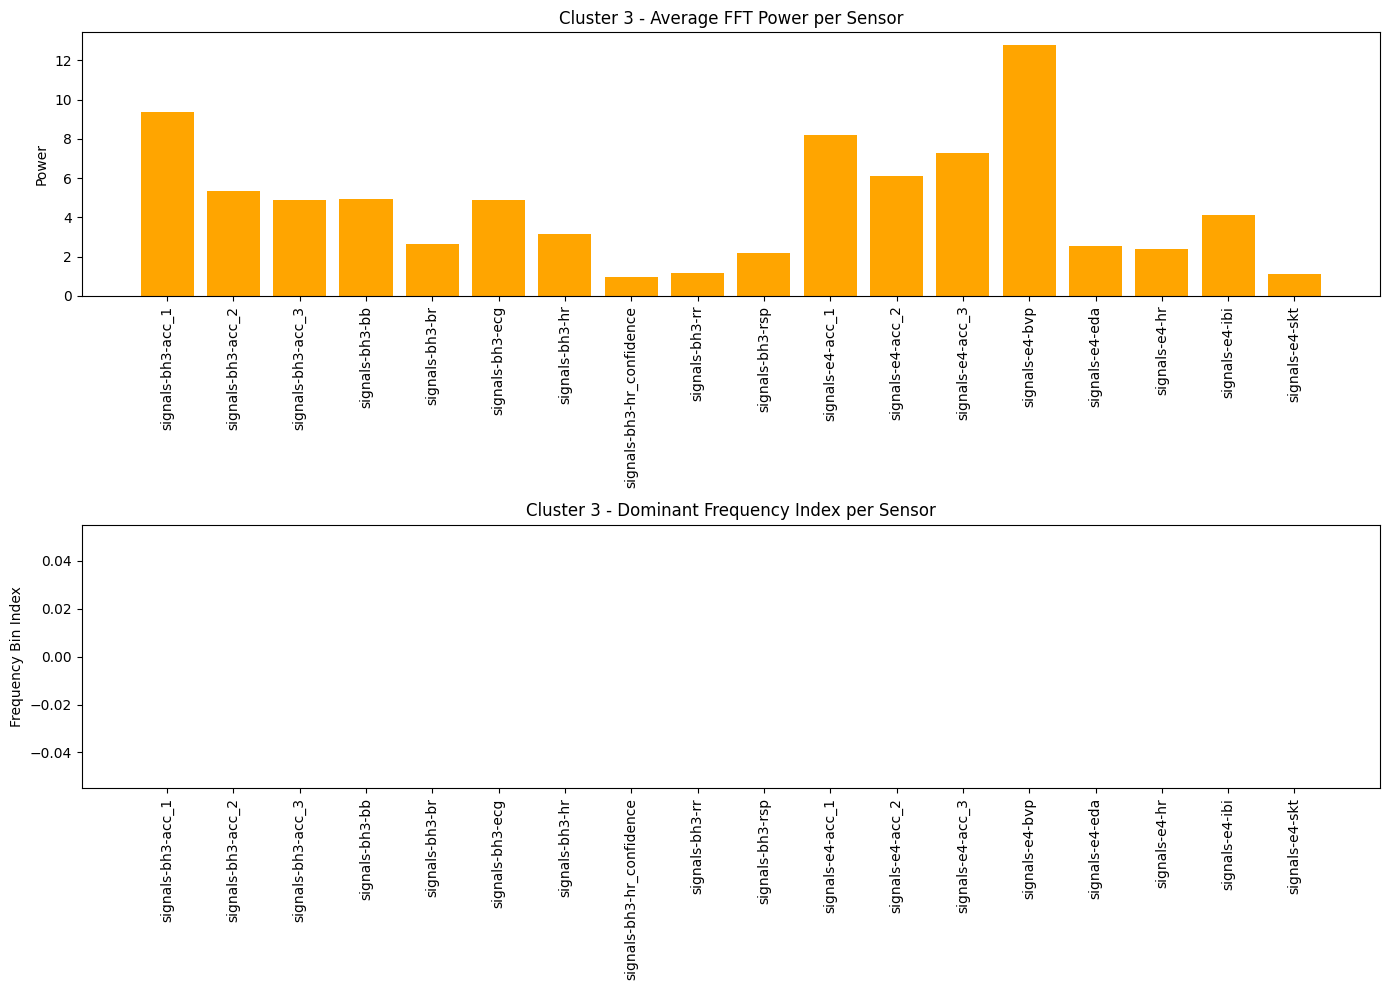

In [19]:
# loop over all clusters and visualize FFT features
for cluster_id in cluster_windows:
    windows = cluster_windows[cluster_id]

    # compute FFT-based stats
    power, freq_idx = compute_fft_features(windows)

    # plot results
    fig, axs = plt.subplots(2, 1, figsize=(14, 10))
    
    axs[0].bar(sensor_names, power, color='orange')
    axs[0].set_title(f"Cluster {cluster_id} - Average FFT Power per Sensor")
    axs[0].set_ylabel('Power')
    axs[0].tick_params(axis='x', rotation=90)

    axs[1].bar(sensor_names, freq_idx, color='orange')
    axs[1].set_title(f"Cluster {cluster_id} - Dominant Frequency Index per Sensor")
    axs[1].set_ylabel("Frequency Bin Index")
    axs[1].tick_params(axis='x', rotation=90)

    plt.tight_layout()
    plt.show()

# Hypotheses from all analyses

## Cluster 0
- High energy/amplitude/std in bh3-ecg (from summary + delta plots)
- Strong FFT power in bh3-ecg and bh3-acc_1, suggesting heart activity + linear movement
- Very low engagement from EDA, SKT, HR, indicating low stress/arousal

Interpretation: Cluster 0 likely represents acute physical activity or movement, such as running, jumping, or a startled motion. The combination of ECG spike and strong uniaxial motion supports a physically intense event rather than stress. Could be short-burst physical exertion or startle response.

## Cluster 1
- Moderate amplitude and energy across most sensors (esp. bb, rr, hr, skt)
- Broad FFT power across bh3-rr, bh3-br, e4-hr
- Dominant frequency in e4-bvp, potentially capturing blood pulse rhythms
- Low motion from BH3 acc, higher skin temp and IBI (suggesting calm/rest)

Interpretation: This cluster represents a light arousal or breathing-regulated state, where the user is mildly engaged (e.g., in focus, meditation, or doing light activities). It may reflect conscious breath control, mild stress, or active calmness. Possibly “mindful alertness.”

# Cluster 2
- Low amplitude/std/energy in most sensors, especially BH3 sensors
- Flat or zero dominant frequency → signals might be flatlined or low-pass dominated
- No sensor clearly dominates in any metric, FFT looks uniformly subdued

Interpretation: Cluster 2 likely represents a deep restful or passive phase, possibly sleep, deep relaxation, or even sensor dropout/poor signal capture. It’s the flattest cluster spectrally and statistically — indicating little to no activity or perhaps poor device adherence.

# Cluster 3
- High amplitude/energy in E4-ACC and E4-BVP (FFT + summary stats)
- Delta plots show strong EDA + motion signals from wrist
- Low BH3 engagement, but moderate E4 activity

Interpretation: Cluster 3 reflects wrist-centric subtle activity, like fidgeting, restless shifting, or low-intensity movement. The strong EDA and BVP suggest emotional micro-responses or agitation, but not full-body motion. Could align with low-key stress or subconscious restlessness.